In [1]:
from utils.binaries import *
from utils.plotting import *

17:36:57 (  +44.3s) [INFO   ] -- import logging
17:36:57 (   +91ms) [INFO   ] -- import numpy as np
17:36:57 (    +4ms) [INFO   ] -- import uncertainties
17:36:57 (  +240ms) [INFO   ] -- import pandas as pd
17:36:57 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
17:36:57 (    +1ms) [INFO   ] -- import binaries.tools as tools
17:36:57 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
17:36:57 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
17:36:57 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
17:36:57 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
17:36:57 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
17:36:57 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
17:36:57 (  +371ms) [INFO   ] -- import matplotlib.pyplot as plt
17:36:58 (  +341ms) [INFO   ] -- import seabor

17:36:58 (   +12ms) [DEBUG  ] -- font size set to 9.5
17:36:58 (    +1ms) [DEBUG  ] -- label size set to 13.0
17:36:58 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
17:36:58 (    +1ms) [DEBUG  ] -- markersize set to 2.0
17:36:58 (    +1ms) [DEBUG  ] -- usetex set to True


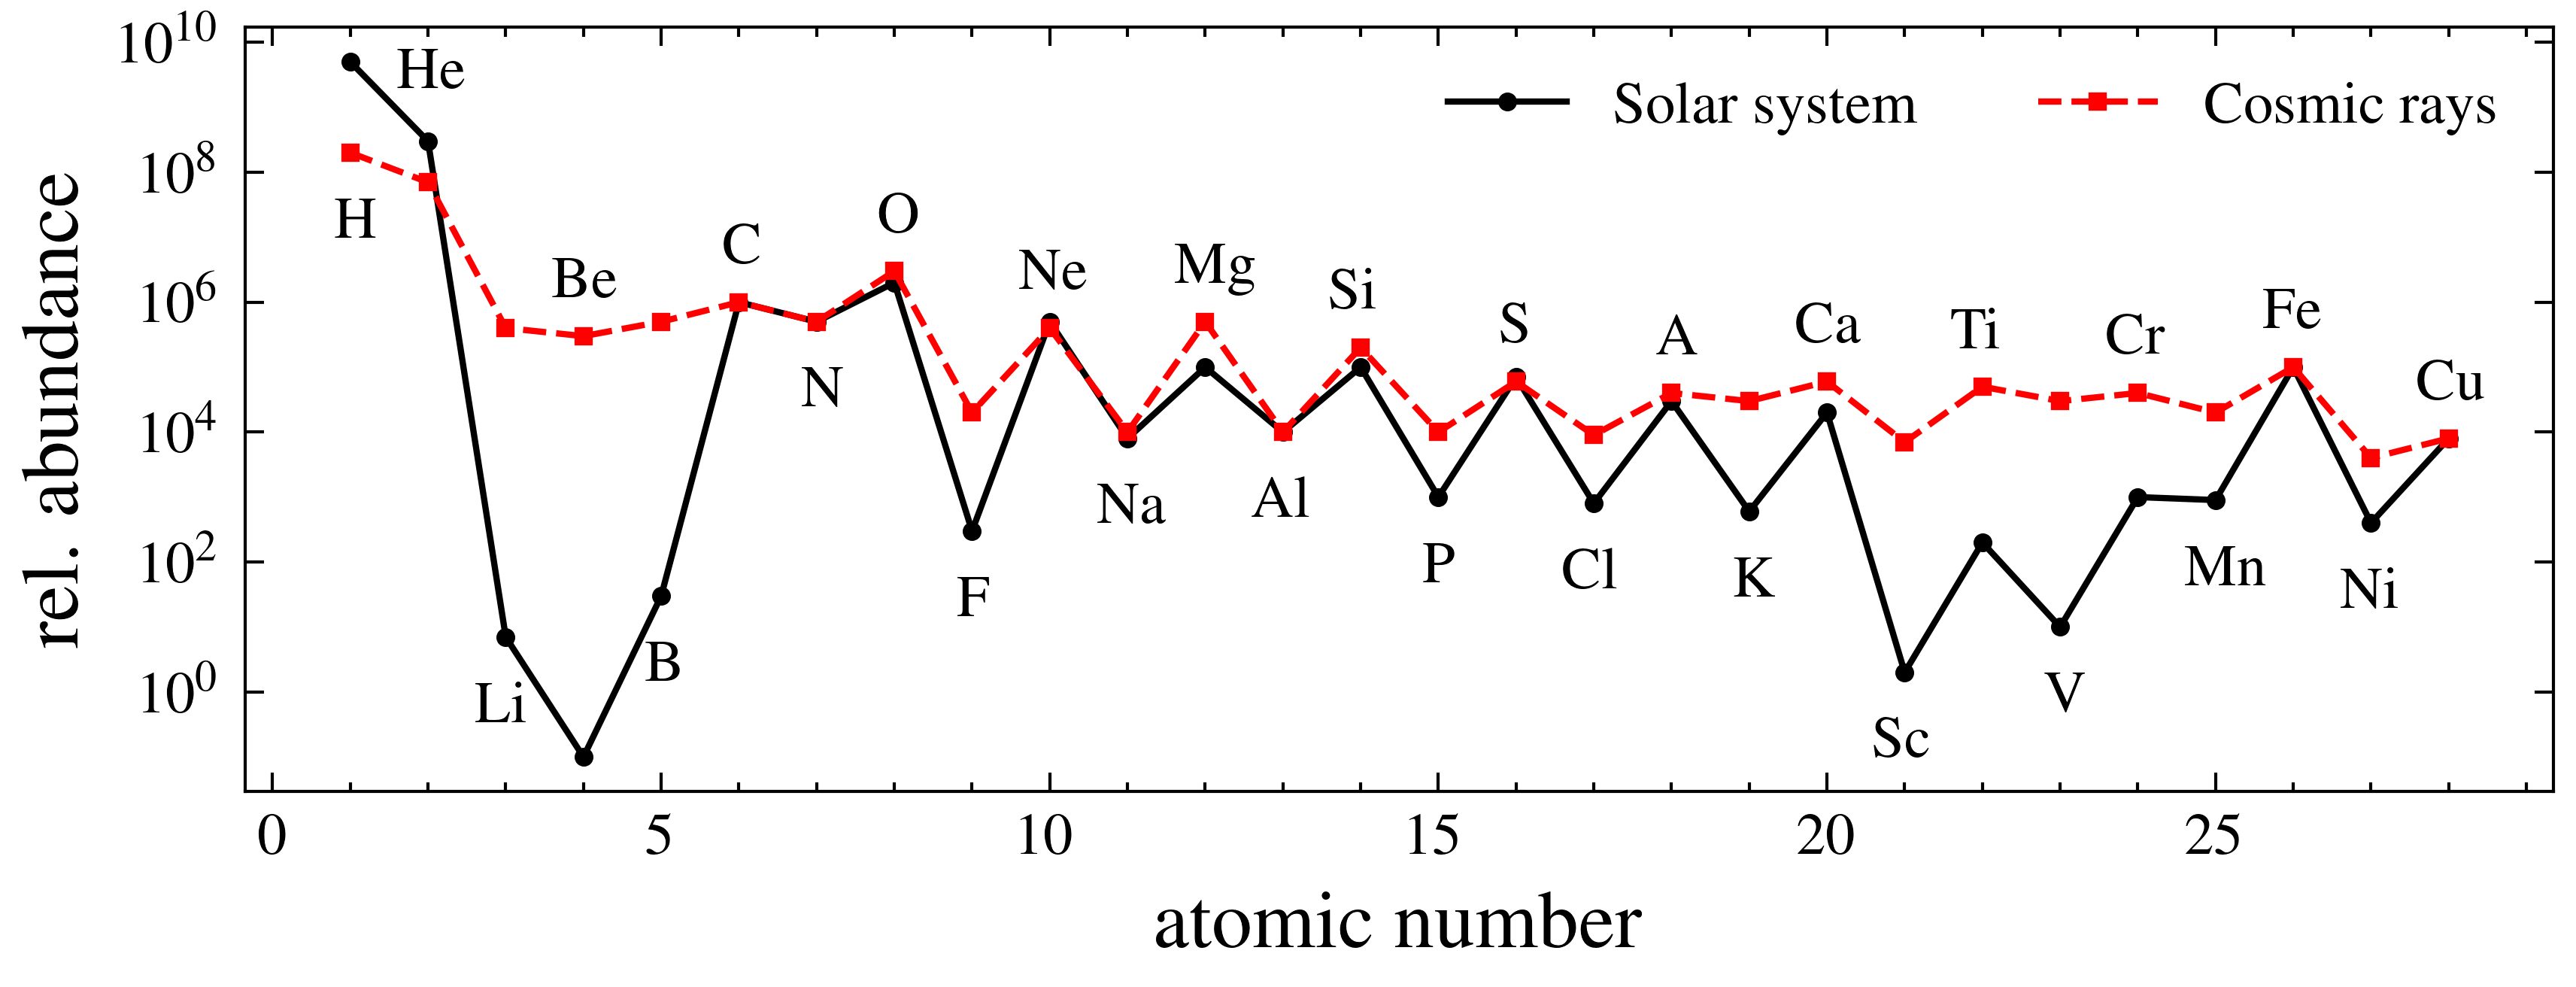

In [2]:
set_plt_style("slim tex")

labels         = ["H","He", "Li"," Be",  "B", "C", "N", "O",  "F","Ne", "Na","Mg","Al","Si",  "P", "S", "Cl", "A",  "K","Ca", "Sc", "Ti",  "V", "Cr", "Mn","Fe", "Ni", "Cu"]
ss_abundancies = [5e5, 3e4, 7e-4, 1e-5, 3e-3, 1e2, 5e1, 2e2, 3e-2, 5e1, 8e-1, 1e1, 1e0, 1e1, 1e-1, 7e0, 8e-2, 3e0, 6e-2, 2e0, 2e-4, 2e-2, 1e-3, 1e-1, 9e-2, 1e1, 4e-2, 8e-1]
cr_abundancies = [2e4, 7e3,  4e1,  3e1,  5e1, 1e2, 5e1, 3e2,  2e0, 4e1,  1e0, 5e1, 1e0, 2e1,  1e0, 6e0, 9e-1, 4e0,  3e0, 6e0, 7e-1,  5e0,  3e0,  4e0,  2e0, 1e1, 4e-1, 8e-1]

atomic_numbers = range(1, 29)
factor = 1e4

for i, label in enumerate(labels, 1):

    match i:
        case 1: height = 1e7
        case 2: height = 2e9
        case x if x % 2 == 0: 
            height = factor * cr_abundancies[i - 1] * 4
        case x if x % 2 != 0:
            height = factor * ss_abundancies[i - 1] * 0.05
            
    plt.text(i - 0.2 if len(label) == 1 else i - 0.4, height, label)

plt.errorbar(atomic_numbers, np.array(ss_abundancies) * factor, marker = "o", label = "Solar system")
plt.errorbar(atomic_numbers, np.array(cr_abundancies) * factor, marker = "s", label = "Cosmic rays")


plt.ylabel("rel. abundance")
plt.xlabel("atomic number")
plt.yscale("log")
plt.legend(ncol=2)

# plt.savefig("../plots/cosmic_ray_composition")

# plt.rcParams["font.size"] = 25
# plt.rcParams["figure.figsize"] = [20, 7]

In [3]:
# https://plotdigitizer.com/app
# https://arxiv.org/pdf/2507.10292

hydrogen = np.array([
17.2561797752809, 0.16019417475728154,
17.355056179775282, 0.2815533980582524,
17.451685393258426, 0.2621359223300971,
17.552808988764045, 0.2766990291262136,
17.64943820224719, 0.1262135922330097,
17.75056179775281, 0.23300970873786406,
17.85168539325843, 0.3058252427184466,
17.95056179775281, 0.3495145631067961,
18.04943820224719, 0.4466019417475728,
18.14831460674157, 0.4174757281553398,
18.24943820224719, 0.37864077669902907,
18.348314606741575, 0.3398058252427184,
18.447191011235955, 0.37378640776699024,
18.548314606741574, 0.22815533980582522,
18.64943820224719, 0.27184466019417475,
18.75056179775281, 0.04368932038834951,
18.849438202247192, 0.0048543689320388345,
18.952808988764044, -0.0048543689320388345,
19.04943820224719, 0,
19.14831460674157, 0.0048543689320388345,
19.251685393258427, 0.07766990291262135,
19.348314606741575, 0.009708737864077669,
19.447191011235955, 0.0048543689320388345,
19.55056179775281, 0.0048543689320388345,
19.7123595505618, 0])

helium = np.array([
17.256887565152642, 0.2378640776699029,
17.35517498138496, -0.0048543689320388345,
17.453462397617276, -0.0048543689320388345,
17.55398361876396, 0.0048543689320388345,
17.654504839910647, 0.3543689320388349,
17.750558451228592, 0.3932038834951456,
17.851079672375278, 0.3058252427184466,
17.949367088607595, 0.2766990291262136,
18.04988830975428, 0.1699029126213592,
18.148175725986597, 0.3252427184466019,
18.248696947133283, 0.41262135922330095,
18.3469843633656, 0.5194174757281553,
18.447505584512285, 0.4805825242718446,
18.54802680565897, 0.616504854368932,
18.64854802680566, 0.4951456310679611,
18.749069247952345, 0.7718446601941746,
18.847356664184662, 0.7815533980582524,
18.95234549516009, 0.8252427184466019,
19.048399106478033, 0.674757281553398,
19.148920327624722, 0.558252427184466,
19.249441548771408, 0.3349514563106796,
19.34772896500372, 0.28640776699029125,
19.44601638123604, 0.19417475728155337,
19.551005212211468, 0.23300970873786406,
19.709605361131793, 0.0048543689320388345])

cno = np.array([
17.259121370067014, 0.35121951219512193,
17.35740878629933, 0.6341463414634146,
17.453462397617276, 0.6780487804878049,
17.55398361876396, 0.624390243902439,
17.650037230081907, 0.3902439024390244,
17.750558451228592, 0.5804878048780487,
17.851079672375278, 0.36585365853658536,
17.949367088607595, 0.35121951219512193,
18.04765450483991, 0.36585365853658536,
18.04765450483991, 0.36585365853658536,
18.145941921072225, 0.24390243902439024,
18.248696947133283, 0.18536585365853658,
18.3469843633656, 0.1073170731707317,
18.447505584512285, 0.13170731707317074,
18.54802680565897, 0.15121951219512195,
18.64854802680566, 0.22926829268292684,
18.746835443037973, 0.18048780487804877,
18.847356664184662, 0.2097560975609756,
18.95011169024572, 0.17073170731707318,
19.04616530156366, 0.32195121951219513,
19.14668652271035, 0.43902439024390244,
19.247207743857036, 0.5853658536585366,
19.345495160089353, 0.7121951219512195,
19.443782576321667, 0.751219512195122,
19.548771407297096, 0.7658536585365854,
19.709605361131793, 0.8829268292682927])

iron = np.array([
17.255988023952096, 0.25728155339805825,
17.352544910179642, 0.08737864077669902,
17.45134730538922, 0.06796116504854369,
17.5501497005988, 0.08737864077669902,
17.648952095808383, 0.1262135922330097,
17.75, 0.058252427184466014,
17.84880239520958, 0.019417475728155338,
17.9498502994012, 0.014563106796116504,
18.04865269461078, 0.0048543689320388345,
18.147455089820358, 0.009708737864077669,
18.24625748502994, 0.014563106796116504,
18.347305389221557, 0.019417475728155338,
18.443862275449103, 0,
18.547155688622755, 0,
18.648203592814372, 0,
18.74700598802395, -0.0048543689320388345,
18.845808383233532, 0,
18.949101796407184, 0,
19.04565868263473, 0,
19.146706586826348, 0,
19.24550898203593, -0.0048543689320388345,
19.34431137724551, 0,
19.44311377245509, 0.04854368932038834,
19.54865269461078, 0,
19.70808383233533, 0.12135922330097086])

17:46:39 (   +6.7s) [DEBUG  ] -- font size set to 9.5
17:46:39 (    +1ms) [DEBUG  ] -- label size set to 13.0
17:46:39 (    +1ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
17:46:39 (    +1ms) [DEBUG  ] -- markersize set to 2.0
17:46:39 (    +1ms) [DEBUG  ] -- usetex set to True


Text(0.5, 0, '$E$ / eV')

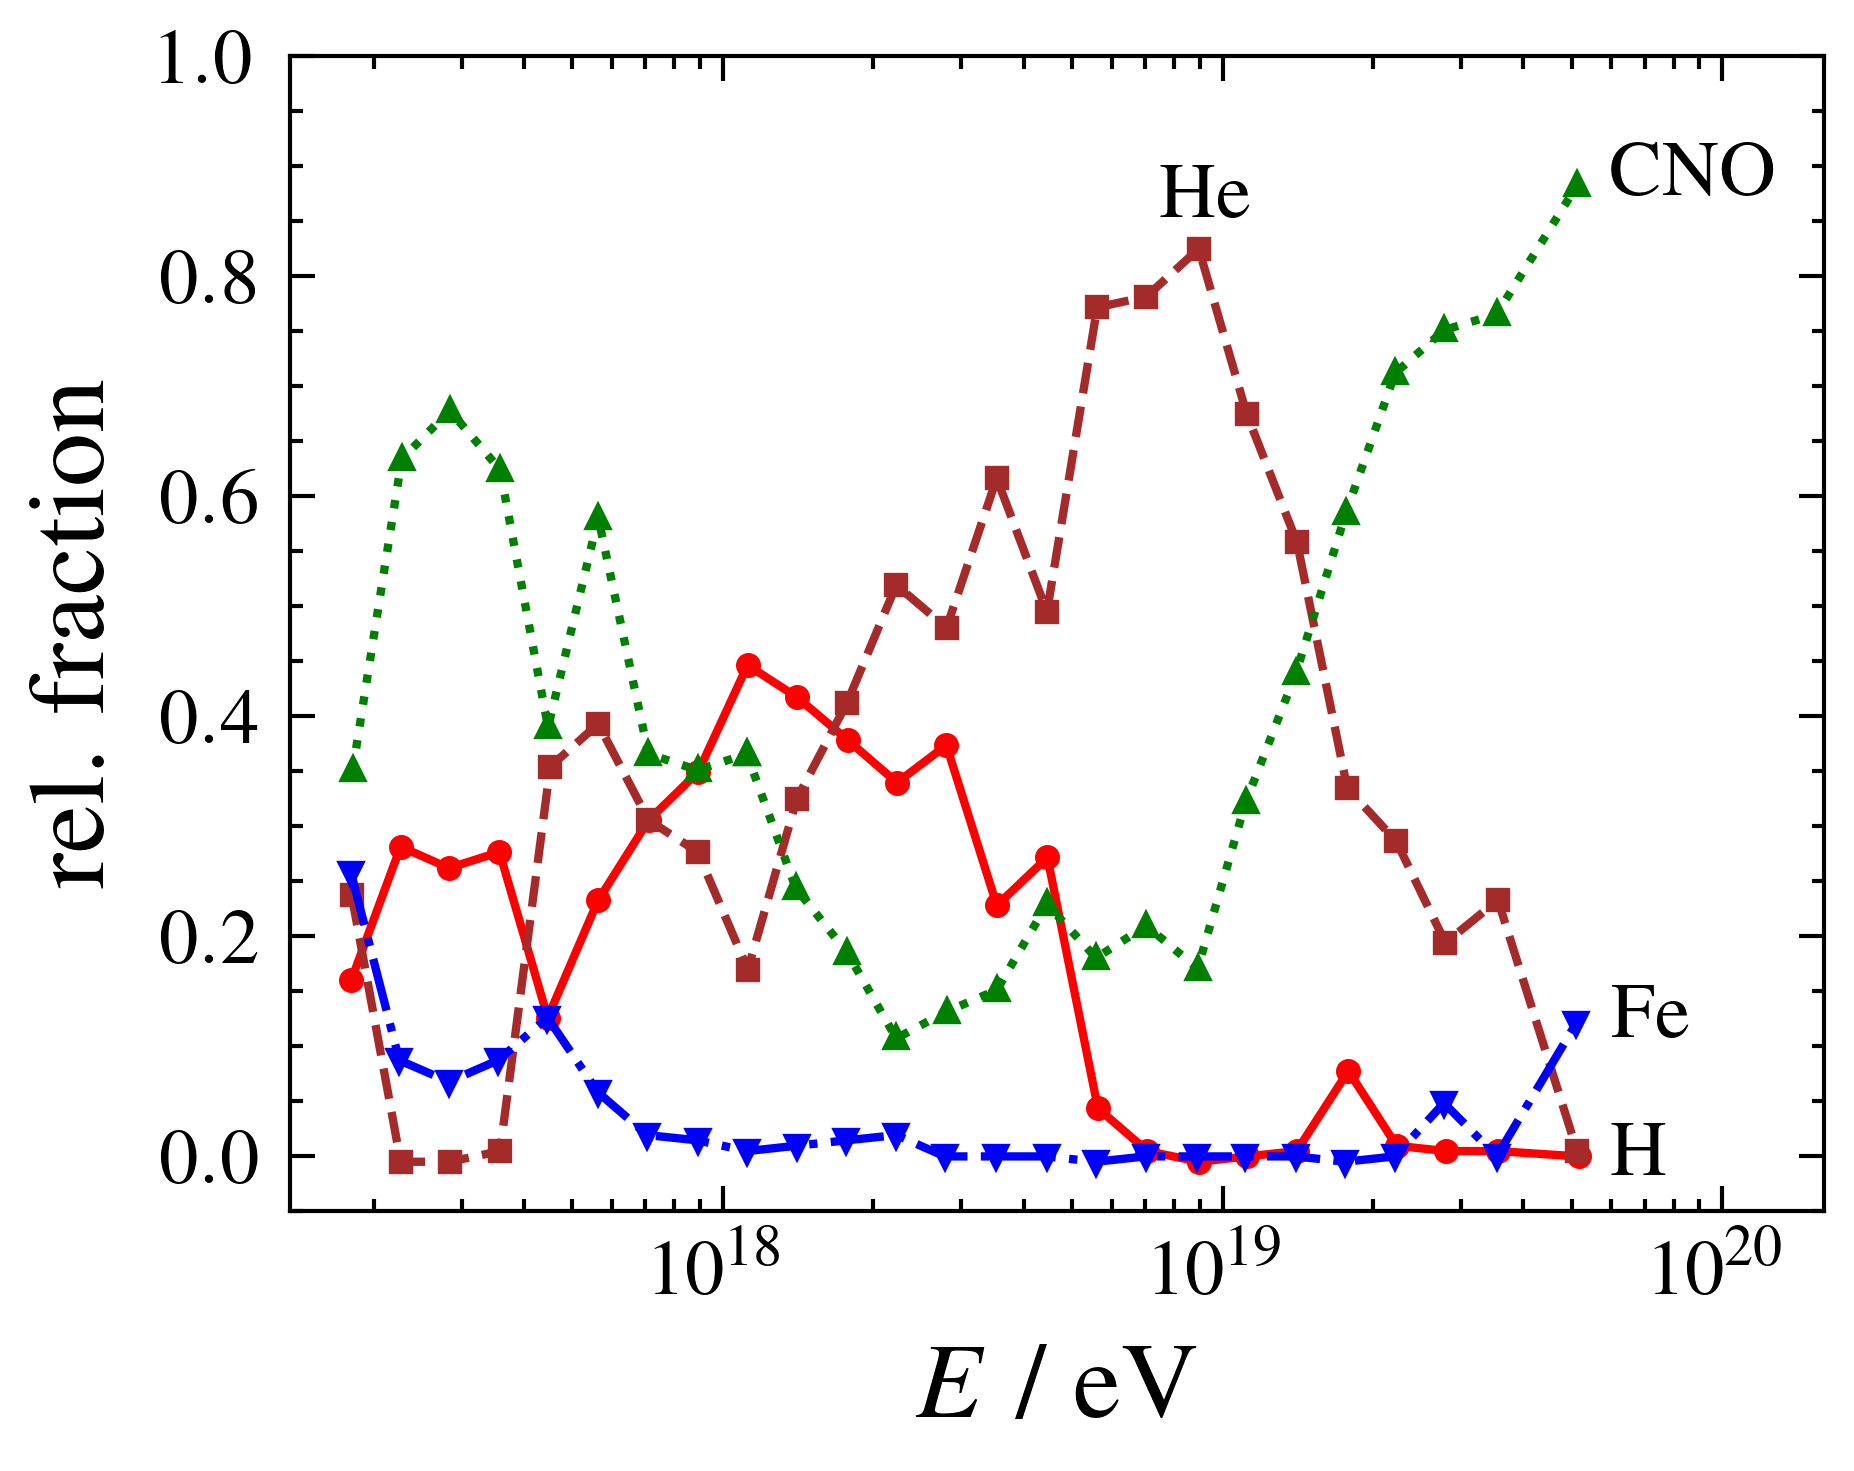

In [36]:
set_plt_style("double tex")

for mass, c, label in zip([hydrogen, helium, cno, iron], 
                          ['r', 'brown', 'g', 'blue'],
                          ["H", "He", "CNO", "Fe"]):
    x, y = mass[::2], mass[1::2]

    plt.plot(10**x, y, c=c) #, label=label)
    # plt.fill_between(10**x, np.minimum([1 for _ in range(len(y))], y + np.abs(np.random.normal(0.1, 0.02, len(x)))),
    #                         np.maximum([0 for _ in range(len(y))], y - np.abs(np.random.normal(0.1, 0.02, len(x)))),
    #                         alpha=0.1, edgecolor='none', color=c, lw=0)

plt.annotate("CNO", (6e19, 0.89), va='center', ha='left')
plt.annotate("Fe", (6e19, 0.125), va='center', ha='left')
plt.annotate("He", (7.5e18, 0.87), va='center', ha='left')
plt.annotate("H", (6e19, 0.), va='center', ha='left')

plt.xscale("log")
plt.xlim(None, 1.6e20)
plt.ylim(-0.05, 1.0)
# plt.legend(ncol=4)
plt.ylabel("rel. fraction")
plt.xlabel("$E$ / eV")


In [5]:
np.minimum(np.array([1 for _ in range(y)]), 0.8*y)

TypeError: only integer scalar arrays can be converted to a scalar index